# Convert Air Team Data from GeoTiff to CSV
Current Air Data is in 162 GeoTiffs. Would like to have 2 CSV files, 1 for 4km and 1 for 1km.

The goal is to make the spatial join with the Housing Unit level data faster.

Code also makes a vector version of the the grids. This will be joined with the point level data. After this join the CSV for the air data will be merged on the grid id.


## Description of Program
- program:    ip1_2bv2_airdata
- task:       Convert geotiffs to csv files
- Version:    2025-12-19
2026-02-23 - update with new common functions
- project:    Southeast Texas Urban Integrated Field Lab
- funding:	  DOE
- author:     Nathanael Rosenheim

## Step 0: Good Housekeeping

In [1]:
# 1. Import all packages
import pandas as pd     # For obtaining and cleaning tabular data
import os                # For file path management

# load the common functions for this project
from ip1_1av1_common import *

In [2]:
# 2. Check versions
import sys
print("Python Version     ", sys.version)
print("pandas version: ", pd.__version__)

Python Version      3.13.9 | packaged by conda-forge | (main, Oct 22 2025, 23:12:41) [MSC v.1944 64 bit (AMD64)]
pandas version:  2.3.3


In [3]:
# 3. Check working directory
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\integrate_people_theme1_cookbook'

In [4]:
#4. Store Program Name for output files to have the same name
programname = "ip1_2bv2_airdata"
# Make directory to save output
if not os.path.exists(programname):
    os.mkdir(programname)

# Step 1: Obtain Data
Obtain publicly available data on CKAN

https://ckan.tacc.utexas.edu/organization/setx-uifl

### Simulated Percentile Concentrations of Hazardous Air Pollutants in Southeast Texas from the Comprehensive Air Quality Model with Extensions
https://ckan.tacc.utexas.edu/dataset/simulated-percentile-concentrations-of-hazardous-air-pollutants

Each file is named according to the following:

Authors: Elena McDonald-Buller; Yosuke Kimura

v720ut3_uifl_4km_1km_rtracv3_*_{gridname}_{species}_ppb_apr_oct_{statistics}.tif

- gridname is grd01 or grd02 specifying the modeling domain, uifl_4km or uifl_1km, respectively
- species can be antl (Acetonitrile), be13 (1,3-Butadiene), benz (Benzene), etbz (Ethylbenzene), etox (Ethylene Oxide), nhex (Hexane), strn (Styrene), tolu (Toluene) or xyln (mixed isomers of Xylenes).
- statistics has the format of pXX where XX is percentile, e.g. p50 represents the 50th percentile, or the word "mean" for mean.


In [5]:
# Add Air Pollution Data
air_pollution_url = "https://ckan.tacc.utexas.edu/dataset/c3c1b2b2-4d43-4603-b1c5-fc0877c279ae/resource/465209c8-f407-4eb2-99b3-4fc719e168c3/download/simulated_percentile_conc.zip"

# start pipeline to read in air team data and convert to csv
air_pollution_dict = load_air_pollution_geotiffs()

Found 162 TIFF files in total

Successfully organized 162 geotiff files into nested dictionary
Resolution levels: ['uifl_1km', 'uifl_4km']

uifl_1km: 9 species
  Benzene: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)
  Acetonitrile: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)
  1,3-Butadiene: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)
  Styrene: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)
  Ethylene Oxide: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)
  Toluene: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)
  Hexane: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)
  Ethylbenzene: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)
  Xylenes: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)

uifl_4km: 9 species
  Benzene: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)
  Acetonitrile: 9 statistics (mean, p100, p25, p50, p75, p90, p95, p98, p99)


In [6]:
air_pollution_dict['uifl_1km']['Benzene']['mean']['data']

array([[[0.02563864, 0.02580572, 0.02594423, ..., 0.0269329 ,
         0.02722025, 0.02728918],
        [0.0256367 , 0.02583389, 0.02600159, ..., 0.02699659,
         0.02721274, 0.02731426],
        [0.02563551, 0.02584121, 0.02599548, ..., 0.02672854,
         0.02706433, 0.02731736],
        ...,
        [0.01703617, 0.01693117, 0.01681641, ..., 0.01405025,
         0.01404103, 0.01402192],
        [0.01686646, 0.01674372, 0.01661937, ..., 0.01400466,
         0.01400023, 0.01399105],
        [0.01668525, 0.01657141, 0.01645894, ..., 0.01395258,
         0.01395216, 0.01395591]]], shape=(1, 72, 72), dtype=float32)

In [7]:
# Build grid tables for each resolution and export CSVs

# 1) Pick one raster from each resolution to define grid geometry
sample_species_1km = next(iter(air_pollution_dict["uifl_1km"]))
sample_stat_1km = next(iter(air_pollution_dict["uifl_1km"][sample_species_1km]))
raster_data_1km = air_pollution_dict["uifl_1km"][sample_species_1km][sample_stat_1km]

sample_species_4km = next(iter(air_pollution_dict["uifl_4km"]))
sample_stat_4km = next(iter(air_pollution_dict["uifl_4km"][sample_species_4km]))
raster_data_4km = air_pollution_dict["uifl_4km"][sample_species_4km][sample_stat_4km]

# 2) Create vector grids
grid_1km_gdf = create_grid_polygons_from_raster(raster_data_1km, "uifl_1km")
grid_4km_gdf = create_grid_polygons_from_raster(raster_data_4km, "uifl_4km")

# 3) Add all species/statistics as columns for each matching resolution
grid_1km_gdf = add_raster_values_to_grid(grid_1km_gdf, air_pollution_dict, "uifl_1km")
grid_4km_gdf = add_raster_values_to_grid(grid_4km_gdf, air_pollution_dict, "uifl_4km")

# 4) Write GPKG + CSV outputs to program folder
output_dir = programname
grid_1km_out, grid_4km_out = write_grid_files(
    grid_1km_gdf=grid_1km_gdf,
    grid_4km_gdf=grid_4km_gdf,
    output_dir=output_dir,
    programname=programname,
    to_wgs84=True,
    include_csv=True,
)

print("Created files:")
print(os.path.join(output_dir, f"{programname}_grid_1km.csv"))
print(os.path.join(output_dir, f"{programname}_grid_4km.csv"))
print(os.path.join(output_dir, f"{programname}_grid_1km.gpkg"))
print(os.path.join(output_dir, f"{programname}_grid_4km.gpkg"))

Creating vector grid from raster:
  Dimensions: 72 x 72 = 5,184 cells
  CRS: PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6370000,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",40],PARAMETER["central_meridian",-97],PARAMETER["standard_parallel_1",33],PARAMETER["standard_parallel_2",45],PARAMETER["false_easting",-252000],PARAMETER["false_northing",1152000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Cell size: 1000.0 x 1000.0 units
Creating polygons for each grid cell...
Successfully created 5,184 grid polygons
Creating vector grid from raster:
  Dimensions: 81 x 99 = 8,019 cells
  CRS: PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6370000,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of

In [8]:
# Quick verification of the CSV outputs
csv_1km = os.path.join(programname, f"{programname}_grid_1km.csv")
csv_4km = os.path.join(programname, f"{programname}_grid_4km.csv")

print("1km exists:", os.path.exists(csv_1km), csv_1km)
print("4km exists:", os.path.exists(csv_4km), csv_4km)

if os.path.exists(csv_1km):
    df1 = pd.read_csv(csv_1km, nrows=5)
    print("1km preview shape:", df1.shape)
    print("1km first columns:", df1.columns[:10].tolist())

if os.path.exists(csv_4km):
    df4 = pd.read_csv(csv_4km, nrows=5)
    print("4km preview shape:", df4.shape)
    print("4km first columns:", df4.columns[:10].tolist())

1km exists: True ip1_2bv2_airdata\ip1_2bv2_airdata_grid_1km.csv
4km exists: True ip1_2bv2_airdata\ip1_2bv2_airdata_grid_4km.csv
1km preview shape: (5, 84)
1km first columns: ['air_grid_id_1km', 'row_idx', 'col_idx', 'uifl_1km_Benzene_p75', 'uifl_1km_Benzene_p100', 'uifl_1km_Benzene_p95', 'uifl_1km_Benzene_p50', 'uifl_1km_Benzene_p25', 'uifl_1km_Benzene_p98', 'uifl_1km_Benzene_p90']
4km preview shape: (5, 84)
4km first columns: ['air_grid_id_4km', 'row_idx', 'col_idx', 'uifl_4km_Benzene_p100', 'uifl_4km_Benzene_p95', 'uifl_4km_Benzene_mean', 'uifl_4km_Benzene_p90', 'uifl_4km_Benzene_p75', 'uifl_4km_Benzene_p50', 'uifl_4km_Benzene_p98']


# Step 2: Visualize Grid Structures

Plotting full 1km grid with 5,184 grid cells

✓ Saved comparison map: ip1_2bv2_airdata\ip1_2bv2_airdata_vector_grids_comparison.png


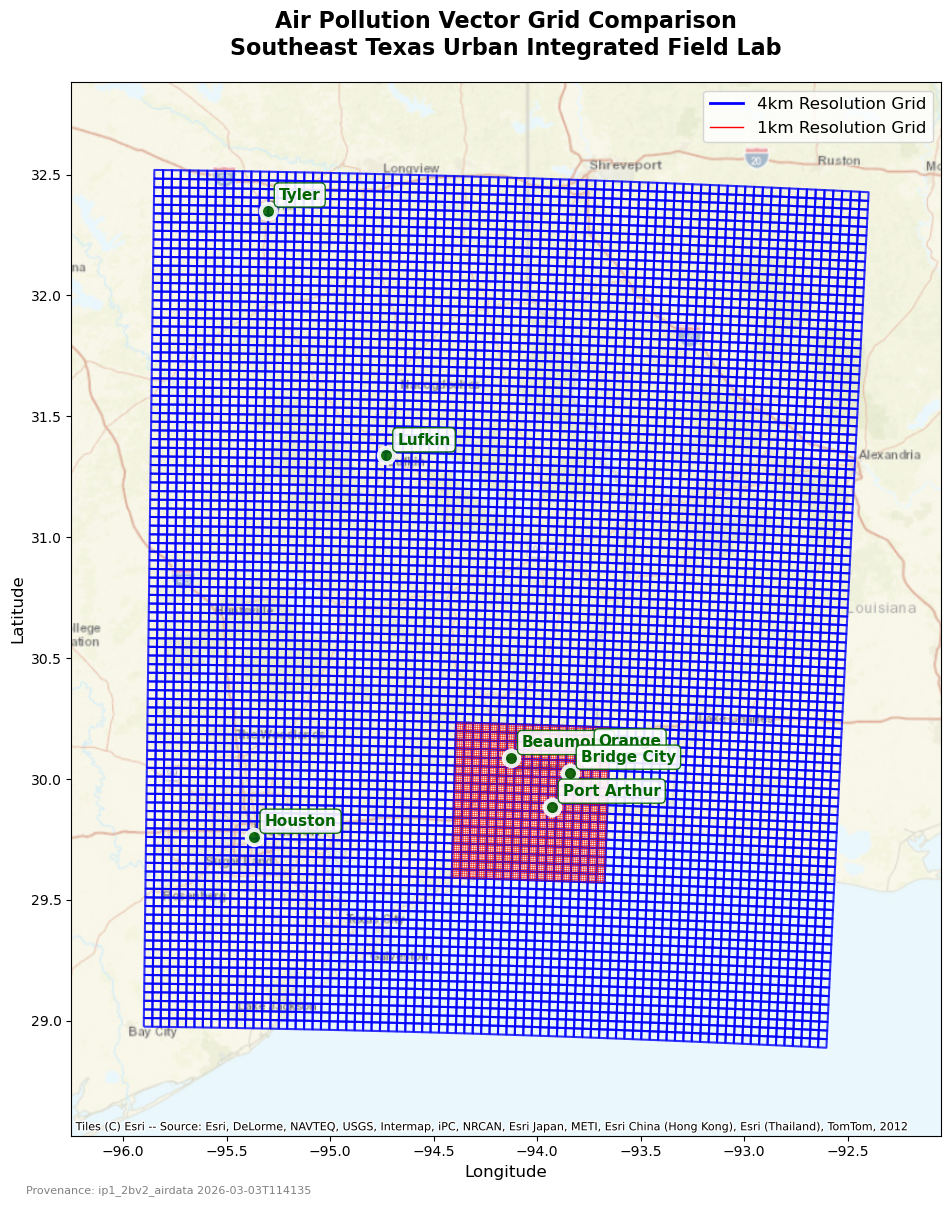


Vector Grid Comparison Summary:
  4km Grid: 8,019 total polygons
  1km Grid: 5,184 total polygons
  Resolution Ratio: 0.6x more cells in 1km
  Average cell area - 4km: 21.5 km², 1km: 1.3 km²


In [9]:
# Compare 4km and 1km grid structures on a single map
plot_vector_grids_comparison(grid_4km_gdf, grid_1km_gdf, programname, output_dir)

In [10]:
grid_1km_gdf.head(1)

,air_grid_id_1km,row_idx,col_idx,geometry,uifl_1km_Benzene_p75,uifl_1km_Benzene_p100,uifl_1km_Benzene_p95,uifl_1km_Benzene_p50,uifl_1km_Benzene_p25,uifl_1km_Benzene_p98,...,uifl_1km_Ethylbenzene_p98,uifl_1km_Xylenes_p98,uifl_1km_Xylenes_mean,uifl_1km_Xylenes_p50,uifl_1km_Xylenes_p95,uifl_1km_Xylenes_p100,uifl_1km_Xylenes_p90,uifl_1km_Xylenes_p75,uifl_1km_Xylenes_p99,uifl_1km_Xylenes_p25
0,airuifl_1km_0000_0000,0,0,"POLYGON ((0 71000, 1000 71000, 1000 72000, 0 7...",0.033394,0.590613,0.06932,0.01865,0.009062,0.097193,...,0.022569,0.055797,0.008866,0.003543,0.038,0.140688,0.024466,0.010385,0.067167,0.000824


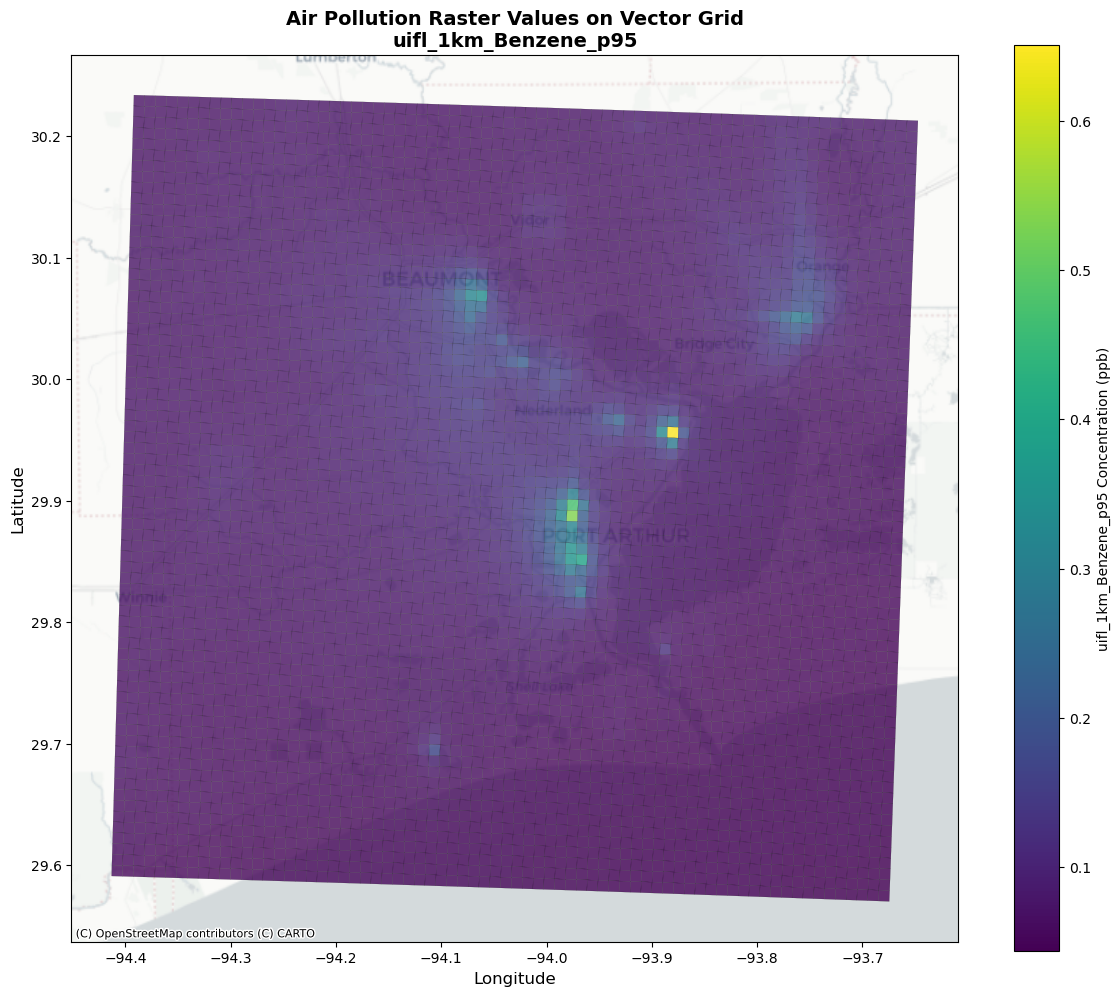

In [11]:
# Plot 1km resolution grid with Benzene p95 values
column_name = "uifl_1km_Benzene_p95"
plot_raster_values_on_grid(grid_1km_gdf, column_name)